## Stress test model to find best performing regions

In [1]:
import torch
import torch.nn as nn
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import sys
from pathlib import Path
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc)
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import copy

In [2]:
# --- 1. SETUP ---
cwd = Path.cwd()
cwd = cwd.parents[1]

In [3]:
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [4]:
try:
    from classifier_siamesemodel_new import SiameseSpectralSimilarityModel
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
except ImportError as e:
    print(f"Error importing modules: {e}")
    sys.exit(1)

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:104: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:128: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dZ):
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:177: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:207: FutureWarning: `to

In [5]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [6]:
# --- 2. CONFIGURATION (EDIT THIS) ---
class NotebookArgs:
    # PATHS
    test_pairs_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
    spec_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
    mol_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
    
    # CONFIGS
    template_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml" 
    custom_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
    
    # WEIGHTS
    checkpoint_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/vicreg/best_vicreg_msgmona.pkl"       # The Encoder Weights
    binary_model_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/binary_classifier/alignuniform/best_focal_model_msgmona.pth" # The Full Model Weights (MLP+Physics)
    
    # OUTPUT
    output_dir = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss"
    
    # SETTINGS
    batch_size = 32
    gpu_id = 0

args = NotebookArgs()
os.makedirs(args.output_dir, exist_ok=True)
device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")

In [7]:
# --- 3. HELPER FUNCTIONS ---

def get_mass_regime(diff):
    if pd.isna(diff): return "Unknown"
    if diff < 0.01: return "0. Exact Isomers (<0.01 Da)"
    elif diff < 1.0: return "1. Isobaric (<1 Da)"
    elif diff < 10.0: return "2. Tiny (1-10 Da)"
    elif diff < 50.0: return "3. Medium (10-50 Da)"
    elif diff < 100.0: return "4. Large (50-100 Da)"
    else: return "5. Huge (>100 Da)"

In [8]:
def calculate_advanced_metrics(df_sub):
    """
    Calculates robust metrics, handling cases with only 1 class.
    """
    y_true = df_sub['label'].values
    y_prob = df_sub['prob'].values
    y_pred = df_sub['pred'].values
    
    # Basic
    metrics = {
        'Count': len(df_sub),
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }
    
    # Advanced (Requires both classes to exist)
    if len(np.unique(y_true)) > 1:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_prob)
        metrics['PR-AUC'] = average_precision_score(y_true, y_prob)
    else:
        metrics['ROC-AUC'] = np.nan # Undefined if only 1 class exists
        metrics['PR-AUC'] = np.nan
        
    return pd.Series(metrics)

In [9]:
def load_and_enrich_data(pairs_path, spec_meta_df):
    """
    Loads pairs, cleans metadata, merges to get precursor masses, 
    and calculates mass difference.
    ROBUST FIX: Handles duplicate columns and indices in spec_meta_df.
    """
    print(f"Loading pairs from: {pairs_path}")
    df_pairs = pd.read_feather(pairs_path)
    
    # --- 1. CLEAN METADATA ---
    # Create a clean copy to avoid modifying the original
    meta_clean = spec_meta_df.copy()
    
    # Ensure spec_id is a column
    if 'spec_id' not in meta_clean.columns:
        # Check if it's in the index
        if meta_clean.index.name == 'spec_id':
            meta_clean = meta_clean.reset_index()
        else:
            # Fallback: Create a column from the index assuming it is spec_id
            meta_clean['spec_id'] = meta_clean.index

    # Identify Mass Column
    mz_col = 'precursor_mz' if 'precursor_mz' in meta_clean.columns else 'prec_mz'
    print(f"Using metadata column: '{mz_col}'")
    
    # CRITICAL FIX: Select only needed columns and drop duplicates
    # This prevents the "DataFrame vs Series" error
    try:
        meta_lookup = meta_clean[['spec_id', mz_col]].copy()
        
        # Remove duplicate columns (if any exist with same name)
        meta_lookup = meta_lookup.loc[:, ~meta_lookup.columns.duplicated()]
        
        # Remove duplicate rows (keep first occurrence of each spec_id)
        meta_lookup = meta_lookup.drop_duplicates(subset=['spec_id'])
        
    except KeyError:
        raise ValueError(f"Column '{mz_col}' not found in metadata. Available: {list(meta_clean.columns)}")

    # --- 2. MERGE MOLECULE A ---
    print("Merging metadata for Molecule A...")
    df_enriched = df_pairs.merge(
        meta_lookup, 
        left_on='name_main', 
        right_on='spec_id', 
        how='left'
    ).rename(columns={mz_col: 'prec_mz_main'}).drop(columns=['spec_id'])
    
    # --- 3. MERGE MOLECULE B ---
    print("Merging metadata for Molecule B...")
    df_enriched = df_enriched.merge(
        meta_lookup, 
        left_on='name_sub', 
        right_on='spec_id', 
        how='left'
    ).rename(columns={mz_col: 'prec_mz_sub'}).drop(columns=['spec_id'])

    print(df_enriched.head())
    
    # --- 4. CALCULATE MASS DIFF ---
    # Now guaranteed to be Series subtraction
    df_enriched['mass_difference'] = (df_enriched['prec_mz_main'] - df_enriched['prec_mz_sub']).abs()
    
    # Handle NaN values (fill with 0 or drop, depending on preference)
    # Here we just warn
    missing = df_enriched['mass_difference'].isna().sum()
    if missing > 0:
        print(f"WARNING: {missing} records have missing mass info (NaN).")
        
    return df_enriched

In [10]:
# --- 4. MAIN EXECUTION ---
def run_evaluation_in_notebook(args):
    print(f"--- STARTING ADVANCED EVALUATION ---")
    
    # A. LOAD DATA
    spec_df_raw = pd.read_pickle(args.spec_data_path)
    spec_df = spec_df_raw.set_index('spec_id')
    mol_df = pd.read_pickle(args.mol_data_path).set_index('mol_id')
    
    # Pre-calculate Mass Diffs
    df_meta = load_and_enrich_data(args.test_pairs_path, spec_df_raw)
    
    # Load Torch Dataset
    test_dataset = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    if len(test_dataset) != len(df_meta): df_meta = df_meta.iloc[:len(test_dataset)]

    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, collate_fn=binary_collate_fn, num_workers=4)
    
    # B. INITIALIZE MODEL
    with open(args.template_config_path, 'r') as f: template_config = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: custom_config = yaml.safe_load(f)
    full_config = merge_configs(template_config, custom_config)
    
    spec_meta_dim = test_dataset[0][2].shape[1]
    
    model = SiameseSpectralSimilarityModel(
        model_config=full_config.get('model', {}),
        checkpoint_path=args.checkpoint_path, 
        spec_meta_dim=spec_meta_dim
    ).to(device)

    print(f"Loading Full Weights: {os.path.basename(args.binary_model_path)}")
    state_dict = torch.load(args.binary_model_path, map_location=device)
    if 'best_model_sd' in state_dict: state_dict = state_dict['best_model_sd']
    elif 'state_dict' in state_dict: state_dict = state_dict['state_dict']
    model.load_state_dict(state_dict)
    model.eval()

    # C. INFERENCE
    print("Running Inference...")
    results = []
    
    with torch.no_grad():
        for batch_idx, (batch_A, batch_B, batch_meta, mass_diffs_tensor, labels) in enumerate(tqdm(test_loader)):
            for k in batch_A: batch_A[k] = batch_A[k].to(device)
            for k in batch_B: batch_B[k] = batch_B[k].to(device)
            batch_meta = batch_meta.to(device)
            mass_diffs_tensor = mass_diffs_tensor.to(device)
            
            logits = model(batch_A, batch_B, batch_meta, mass_diffs_tensor).view(-1)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(float)
            labels = labels.numpy()
            
            start_idx = batch_idx * args.batch_size
            for i in range(len(probs)):
                global_idx = start_idx + i
                if global_idx >= len(df_meta): break
                
                row = df_meta.iloc[global_idx]
                mass_diff = row['mass_difference']
                
                results.append({
                    'prob': probs[i],
                    'pred': preds[i],
                    'label': labels[i],
                    'mass_diff': mass_diff
                })

    df_res = pd.DataFrame(results)
    
    # D. ADVANCED METRICS & PLOTTING
    print("\n" + "="*40)
    print("      MASS REGIME METRICS      ")
    print("="*40)

    # 1. METRICS TABLE
    df_res['mass_regime'] = df_res['mass_diff'].apply(get_mass_regime)
    mass_stats = df_res.groupby('mass_regime', observed=False).apply(calculate_advanced_metrics)
    print("\n[1] Metrics by Mass Difference:")
    print(mass_stats[['Count', 'ROC-AUC', 'PR-AUC', 'Accuracy']])

    # 2. PLOTTING ROC AND PR CURVES
    plt.figure(figsize=(20, 8)) # Wider figure for side-by-side plots

    # --- PLOT A: ROC CURVES ---
    plt.subplot(1, 2, 1)
    for regime in sorted(df_res['mass_regime'].unique()):
        subset = df_res[df_res['mass_regime'] == regime]
        if len(subset['label'].unique()) > 1:
            fpr, tpr, _ = roc_curve(subset['label'], subset['prob'])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{regime} (AUC = {roc_auc:.2f})', linewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves by Mass Regime')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # --- PLOT B: PRECISION-RECALL CURVES (NEW!) ---
    plt.subplot(1, 2, 2)
    for regime in sorted(df_res['mass_regime'].unique()):
        subset = df_res[df_res['mass_regime'] == regime]
        if len(subset['label'].unique()) > 1:
            precision, recall, _ = precision_recall_curve(subset['label'], subset['prob'])
            pr_auc = average_precision_score(subset['label'], subset['prob'])
            
            # Baseline (Random Guessing) is P / (P + N)
            baseline = subset['label'].mean()
            
            plt.plot(recall, precision, label=f'{regime} (AP = {pr_auc:.2f})', linewidth=2)
    
    # Plot baseline for total dataset average
    total_baseline = df_res['label'].mean()
    plt.axhline(y=total_baseline, color='k', linestyle='--', label=f'Random ({total_baseline:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves by Mass Regime')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    

    # Save
    save_path = os.path.join(args.output_dir, "mass_regime_metrics.csv")
    df_res.to_csv(save_path, index=False)
    print(f"Results saved to {save_path}")

--- STARTING ADVANCED EVALUATION ---
Loading pairs from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather
Using metadata column: 'prec_mz'
Merging metadata for Molecule A...
Merging metadata for Molecule B...
              name_main              name_sub  tanimoto  cosine_similarity  \
0  MassSpecGymID0003031  MassSpecGymID0049401  0.432432           0.706041   
1  MassSpecGymID0223776  MassSpecGymID0237961  0.175676           0.648690   
2  MassSpecGymID0224062  MassSpecGymID0234208  0.089109           0.122628   
3  MassSpecGymID0003081  MassSpecGymID0060725  0.439024           0.773729   
4  MassSpecGymID0148794  MassSpecGymID0159098  0.403846           0.449861   

   label  prec_mz_main  prec_mz_sub  
0    1.0     495.26590    411.17200  
1    0.0     534.08809    280.14444  
2    0.0     412.21185    483.20134  
3    1.0     363.17200    293.09370  
4    0.0     245.11720    259.09650  
Loading binary pairs from /data/n

/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/classifier_siamesemodel_new.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkp

Siamese Model Initialized (Decoupled Architecture).
  - Head Input Dim: 82
  - Mass Gating Active
Loading Full Weights: best_focal_model_msgmona.pth


/tmp/ipykernel_526072/1318097729.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(args.binary_model_path, map_location=device)


Running Inference...


100%|██████████| 152/152 [00:11<00:00, 13.14it/s]



      MASS REGIME METRICS      

[1] Metrics by Mass Difference:
                              Count   ROC-AUC    PR-AUC  Accuracy
mass_regime                                                      
0. Exact Isomers (<0.01 Da)   567.0  0.647534  0.946925  0.890653
1. Isobaric (<1 Da)            36.0  0.635417  0.619623  0.472222
2. Tiny (1-10 Da)             353.0  0.785857  0.746442  0.739377
3. Medium (10-50 Da)         1757.0  0.829997  0.834548  0.783153
4. Large (50-100 Da)         1026.0  0.840801  0.764178  0.765107
5. Huge (>100 Da)            1119.0  0.803652  0.596311  0.798034


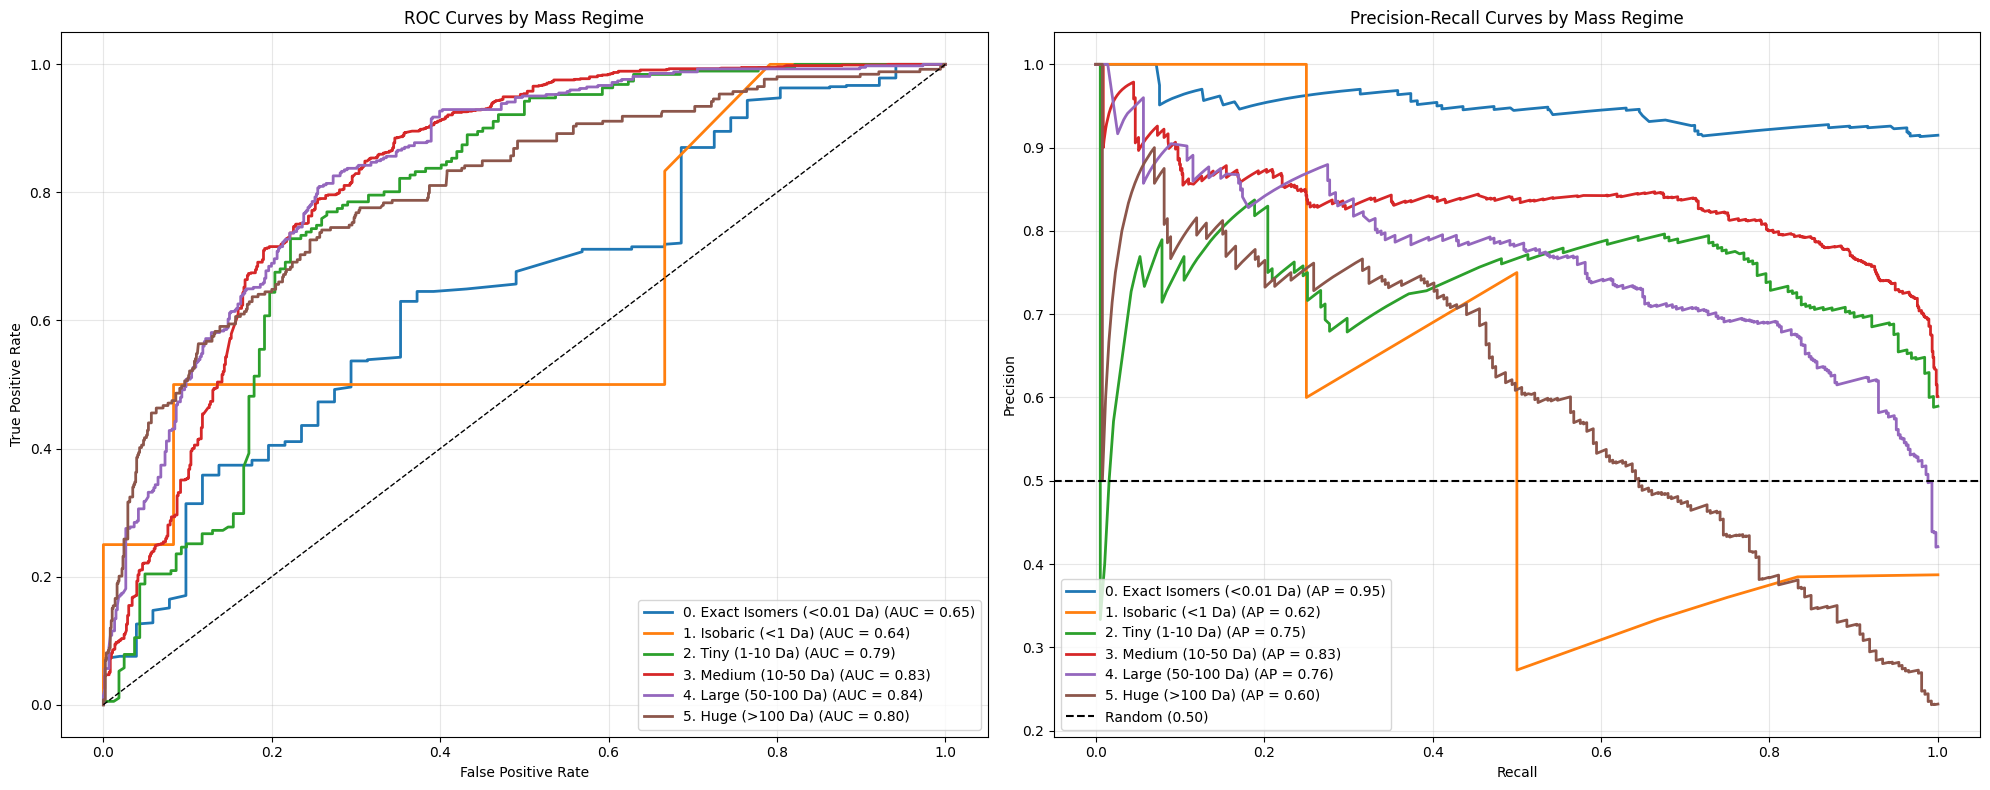

Results saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/mass_regime_metrics.csv


In [11]:
# --- 5. RUN IT ---
run_evaluation_in_notebook(args)

## Stress test model performance across cosine similarity

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [13]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv"
TEST_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
OUTPUT_DIR = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [14]:
def analyze_similarity_spectrum():
    print("--- PERFORMANCE VS. SPECTRAL SIMILARITY ---")
    
    # 1. Load Results directly (No external metadata needed!)
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find file at {RESULTS_PATH}")
        return

    print(f"Loading results from {RESULTS_PATH}...")
    df_analysis = pd.read_csv(RESULTS_PATH)
    
    # 2. Binning the Ground Truth Similarity
    # We use the 'cosine_similarity' column from your CSV
    # Bins: 0.0-0.1, 0.1-0.2, ... 0.9-1.0
    bins = np.linspace(0, 1.0, 11)
    labels = [f"{i/10:.1f}-{(i+1)/10:.1f}" for i in range(10)]
    
    df_analysis['sim_bin'] = pd.cut(
        df_analysis['cosine_similarity'], 
        bins=bins, 
        labels=labels, 
        include_lowest=True
    )
    
    # 3. Calculate Metrics per Bin
    print("Calculating metrics per bin...")
    
    # Helper to calculate metrics safely (handling empty bins)
    def calc_metrics(x):
        if len(x) == 0:
            return pd.Series({'Count': 0, 'Accuracy': np.nan, 'Avg_Conf': np.nan, 'Pos_Rate': 0})
            
        return pd.Series({
            'Count': len(x),
            'Accuracy': accuracy_score(x['true_label'], x['predicted_label']),
            'Precision': precision_score(x['true_label'], x['predicted_label'], zero_division=0),
            'Recall': recall_score(x['true_label'], x['predicted_label'], zero_division=0),
            'Avg_Conf': x['prob_similarity'].mean(),
            'Pos_Rate': x['true_label'].mean() # How many are actually Positive in this bin?
        })

    spectrum_stats = df_analysis.groupby('sim_bin', observed=False).apply(calc_metrics)
    
    print("\nSpectrum Performance Table:")
    print(spectrum_stats[['Count', 'Accuracy', 'Precision', 'Recall', 'Pos_Rate']])
    
    # 4. VISUALIZATION
    plt.figure(figsize=(14, 7))
    
    # Plot 1: Accuracy Line (Primary Axis)
    ax1 = plt.gca()
    sns.lineplot(data=spectrum_stats, x=spectrum_stats.index, y='Accuracy', 
                 marker='o', color='tab:blue', linewidth=3, label='Model Accuracy', ax=ax1)
    
    # Plot 2: Sample Count Bar (Secondary Axis)
    ax2 = ax1.twinx()
    sns.barplot(data=spectrum_stats, x=spectrum_stats.index, y='Count', 
                color='gray', alpha=0.2, ax=ax2, label='Sample Count')
    
    # Formatting
    ax1.set_ylabel('Accuracy', color='tab:blue', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel("Ground Truth Cosine Similarity", fontsize=12)
    ax1.grid(alpha=0.3)
    
    ax2.set_ylabel('Number of Pairs', color='gray', fontsize=12)
    ax2.grid(False) # Turn off grid for secondary axis to avoid clutter
    
    # Add Threshold Line
    plt.axvline(x=6.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary (0.7)')
    
    # Combined Legend
    lines, labels1 = ax1.get_legend_handles_labels()
    bars, labels2 = ax2.get_legend_handles_labels()
    # Manually adding the red line to legend
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='red', linestyle='--', lw=2)]
    
    ax1.legend(lines + bars + custom_lines, labels1 + labels2 + ['Decision Boundary'], loc='upper left')
    
    plt.title("Model Accuracy across Ground Truth Similarity Spectrum", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # 5. Show and Save
    plt.show() # 
    
    save_csv_path = os.path.join(OUTPUT_DIR, "spectrum_metrics.csv")
    spectrum_stats.to_csv(save_csv_path)
    print(f"Detailed metrics saved to {save_csv_path}")

--- PERFORMANCE VS. SPECTRAL SIMILARITY ---
Loading results from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv...
Calculating metrics per bin...

Spectrum Performance Table:
         Count  Accuracy  Precision    Recall  Pos_Rate
sim_bin                                                
0.0-0.1  347.0  0.936599        0.0  0.000000       0.0
0.1-0.2  347.0  0.890490        0.0  0.000000       0.0
0.2-0.3  347.0  0.847262        0.0  0.000000       0.0
0.3-0.4  347.0  0.752161        0.0  0.000000       0.0
0.4-0.5  347.0  0.645533        0.0  0.000000       0.0
0.5-0.6  347.0  0.533141        0.0  0.000000       0.0
0.6-0.7  347.0  0.345821        0.0  0.000000       0.0
0.7-0.8  689.0  0.785196        1.0  0.785196       1.0
0.8-0.9  787.0  0.895807        1.0  0.895807       1.0
0.9-1.0  953.0  0.916055        1.0  0.916055       1.0


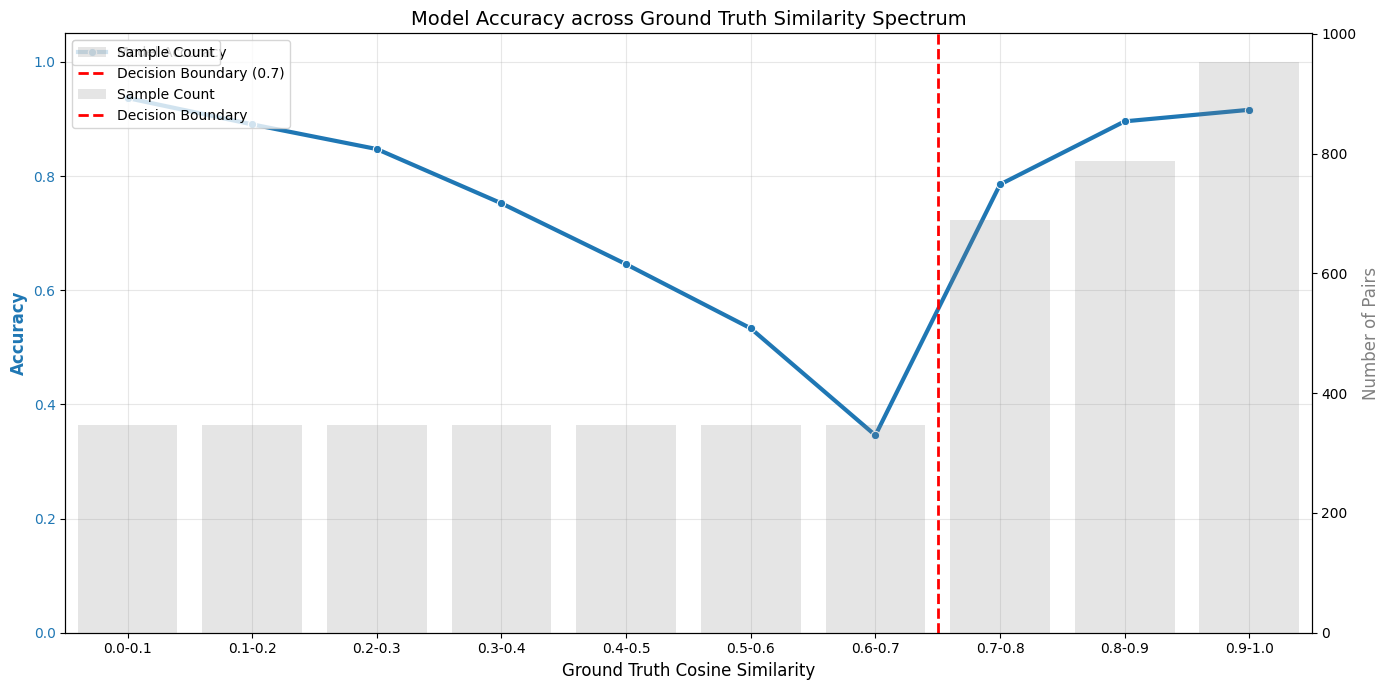

Detailed metrics saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/spectrum_metrics.csv


In [15]:
# Run
analyze_similarity_spectrum()

## Honest Accuracy Metrics

In [16]:
import pandas as pd
import numpy as np
import os
import sys
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [17]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv" # From previous step
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
OUTPUT_DIR = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [18]:
def run_final_clean_eval():
    print("--- GENERATING FINAL PUBLICATION METRICS ---")
    
    # 1. LOAD RESULTS
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results file at {RESULTS_PATH}")
        return

    print(f"Loading results from {RESULTS_PATH}...")
    df_results = pd.read_csv(RESULTS_PATH)
    
    # 2. LOAD METADATA & ENRICH
    print(f"Loading metadata from {SPEC_DATA_PATH}...")
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    # Ensure index is set for fast lookup
    if 'spec_id' in spec_df.columns:
        spec_df = spec_df.set_index('spec_id')
    
    # Identify Mass Column (Handle potential naming variations)
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    print(f"Using mass column: '{mz_col}'")
    
    # Create a lightweight lookup series
    mass_lookup = spec_df[mz_col]
    
    print("Enriching results with Mass Difference...")
    # Map masses to the results dataframe
    # map() is faster than merge() for single-column lookups on index
    df_results['mz_main'] = df_results['name_main'].map(mass_lookup)
    df_results['mz_sub'] = df_results['name_sub'].map(mass_lookup)
    
    # Calculate Difference
    df_results['mass_diff'] = (df_results['mz_main'] - df_results['mz_sub']).abs()
    
    # Drop rows where mass lookup failed (if any)
    n_before = len(df_results)
    df_results = df_results.dropna(subset=['mass_diff'])
    n_after = len(df_results)
    if n_before != n_after:
        print(f"Warning: Dropped {n_before - n_after} rows due to missing metadata.")

    # 3. APPLY "BLIND TRUST" FILTER
    # Filter: 1.0 <= Mass Diff <= 100.0
    print("\nApplying Trust Filter: 1.0 Da <= Mass Diff <= 100.0 Da")
    
    mask_trust = (df_results['mass_diff'] >= 1.0) & (df_results['mass_diff'] <= 100.0)
    df_clean = df_results[mask_trust].copy()
    
    n_excluded = n_after - len(df_clean)
    
    print(f"Total Evaluated Pairs: {n_after:,}")
    print(f"Cleaned Subset:        {len(df_clean):,} (The 'Gold Standard')")
    print(f"Excluded Artifacts:    {n_excluded:,} (Isomers & Huge Diffs)")

    # 4. CALCULATE METRICS
    # Use the columns from your provided CSV structure
    y_true = df_clean['true_label'].values
    y_pred = df_clean['predicted_label'].values
    y_prob = df_clean['prob_similarity'].values
    
    metrics = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
        'Score': [
            accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred),
            recall_score(y_true, y_pred),
            f1_score(y_true, y_pred),
            roc_auc_score(y_true, y_prob)
        ]
    }
    
    df_metrics = pd.DataFrame(metrics)
    
    # 5. DISPLAY & EXPORT
    print("\n" + "="*40)
    print("  FINAL PUBLISHABLE RESULTS (CLEAN SUBSET)  ")
    print("="*40)
    print(df_metrics.to_string(index=False, formatters={'Score': '{:.4f}'.format}))
    
    save_path = os.path.join(OUTPUT_DIR, "final_clean_metrics.csv")
    df_metrics.to_csv(save_path, index=False)
    print(f"\nMetrics saved to {save_path}")
    
    # Save the enriched dataset for reference
    data_save_path = os.path.join(OUTPUT_DIR, "clean_test_subset_enriched.csv")
    df_clean.to_csv(data_save_path, index=False)
    print(f"Cleaned dataset saved to {data_save_path}")

In [19]:
run_final_clean_eval()

--- GENERATING FINAL PUBLICATION METRICS ---
Loading results from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv...
Loading metadata from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Using mass column: 'prec_mz'
Enriching results with Mass Difference...

Applying Trust Filter: 1.0 Da <= Mass Diff <= 100.0 Da
Total Evaluated Pairs: 4,858
Cleaned Subset:        3,136 (The 'Gold Standard')
Excluded Artifacts:    1,722 (Isomers & Huge Diffs)

  FINAL PUBLISHABLE RESULTS (CLEAN SUBSET)  
   Metric  Score
 Accuracy 0.7723
Precision 0.7322
   Recall 0.8910
 F1 Score 0.8038
  ROC-AUC 0.8358

Metrics saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/final_clean_metrics.csv
Cleaned dataset saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/clean_test_subset_enriched.csv


In [20]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

In [21]:
def plot_honest_curves():
    print("--- GENERATING HONEST EVALUATION CURVES ---")
    
    # 1. LOAD & ENRICH (Same as before)
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results file at {RESULTS_PATH}")
        return

    print("Loading and enriching data...")
    df_results = pd.read_csv(RESULTS_PATH)
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    if 'spec_id' in spec_df.columns: spec_df = spec_df.set_index('spec_id')
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    
    # Map Masses
    mass_lookup = spec_df[mz_col]
    df_results['mz_main'] = df_results['name_main'].map(mass_lookup)
    df_results['mz_sub'] = df_results['name_sub'].map(mass_lookup)
    df_results['mass_diff'] = (df_results['mz_main'] - df_results['mz_sub']).abs()
    
    # 2. APPLY TRUST FILTER
    print("Applying Trust Filter (1.0 - 100.0 Da)...")
    mask_trust = (df_results['mass_diff'] >= 1.0) & (df_results['mass_diff'] <= 100.0)
    df_clean = df_results[mask_trust].copy()
    
    print(f"Plotting curves for {len(df_clean):,} validated pairs.")

    # 3. CALCULATE CURVES
    y_true = df_clean['true_label'].values
    y_prob = df_clean['prob_similarity'].values
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()

    # 4. PLOTTING
    plt.figure(figsize=(16, 7))
    
    # --- PLOT A: HONEST ROC ---
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Physics-Aware Model (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Honest ROC Curve\n(Artifacts Removed)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    

    # --- PLOT B: HONEST PR ---
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', lw=3, label=f'Physics-Aware Model (AP = {pr_auc:.3f})')
    plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Random ({baseline:.2f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Honest Precision-Recall Curve\n(Artifacts Removed)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(alpha=0.3)
    

    plt.tight_layout()
    
    # 5. SAVE
    plot_path = os.path.join(OUTPUT_DIR, "honest_evaluation_curves.png")
    plt.savefig(plot_path, dpi=300)
    print(f"\nHigh-resolution plots saved to: {plot_path}")
    plt.show()

--- GENERATING HONEST EVALUATION CURVES ---
Loading and enriching data...
Applying Trust Filter (1.0 - 100.0 Da)...
Plotting curves for 3,136 validated pairs.

High-resolution plots saved to: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/honest_evaluation_curves.png


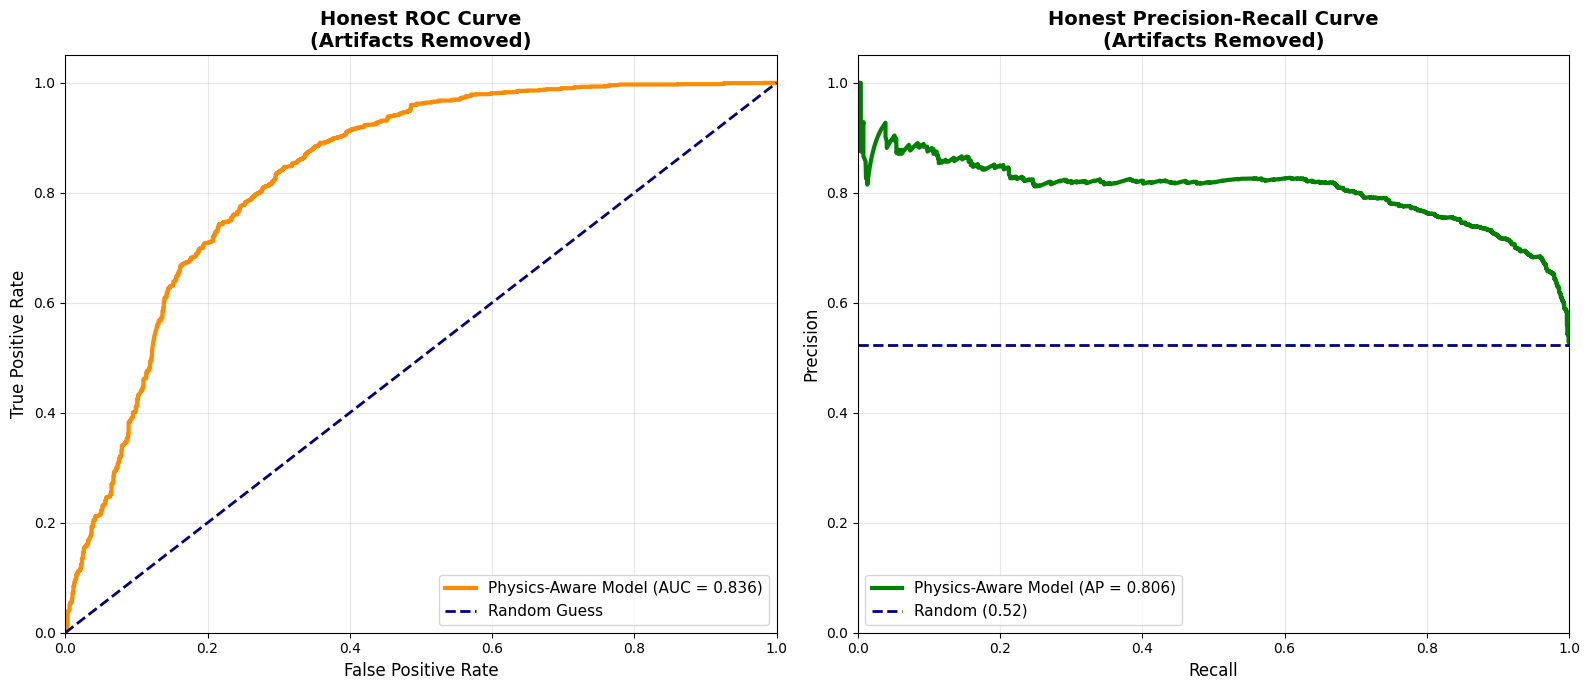

In [22]:
plot_honest_curves()

## Analyzing performance of the model in high confidence areas of spectral similarity

In [23]:
import pandas as pd
import numpy as np
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score

In [25]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/align_uniform/msgmona/results_stratified_binary_07_dataset_test.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
OUTPUT_DIR = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [26]:
def plot_honest_curves():
    print("--- VISUALIZING CURVES FOR HONEST SPECTRUM (1-100 Da) ---")
    
    # 1. LOAD & ENRICH
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results file at {RESULTS_PATH}")
        return

    print("Loading results and enriching with mass data...")
    df = pd.read_csv(RESULTS_PATH)
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    if 'spec_id' in spec_df.columns: spec_df = spec_df.set_index('spec_id')
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    
    # Map Masses
    mass_lookup = spec_df[mz_col]
    df['mz_main'] = df['name_main'].map(mass_lookup)
    df['mz_sub'] = df['name_sub'].map(mass_lookup)
    df['mass_diff'] = (df['mz_main'] - df['mz_sub']).abs()
    
    # 2. APPLY TRUST FILTER (1-100 Da)
    mask_trust = (df['mass_diff'] >= 1.0) & (df['mass_diff'] <= 100.0)
    df_clean = df[mask_trust].copy()
    
    print(f"Plotting for subset: {len(df_clean):,} pairs (Analogs Only)")

    # 3. CALCULATE CURVES
    y_true = df_clean['true_label'].values
    y_prob = df_clean['prob_similarity'].values
    
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()

    # 4. PLOTTING
    plt.figure(figsize=(16, 7))
    
    # --- PLOT A: ROC CURVE ---
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Honest AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Honest ROC Curve\n(1-100 Da Subset)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    
    # --- PLOT B: PRECISION-RECALL CURVE ---
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', lw=3, label=f'Honest AP = {pr_auc:.3f}')
    plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Random ({baseline:.2f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Honest Precision-Recall Curve\n(1-100 Da Subset)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # 5. SAVE
    plot_path = os.path.join(OUTPUT_DIR, "honest_spectrum_curves.png")
    plt.savefig(plot_path, dpi=300)
    print(f"\nCurves saved to {plot_path}")
    plt.show()

--- VISUALIZING CURVES FOR HONEST SPECTRUM (1-100 Da) ---
Loading results and enriching with mass data...
Plotting for subset: 3,136 pairs (Analogs Only)

Curves saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/honest_spectrum_curves.png


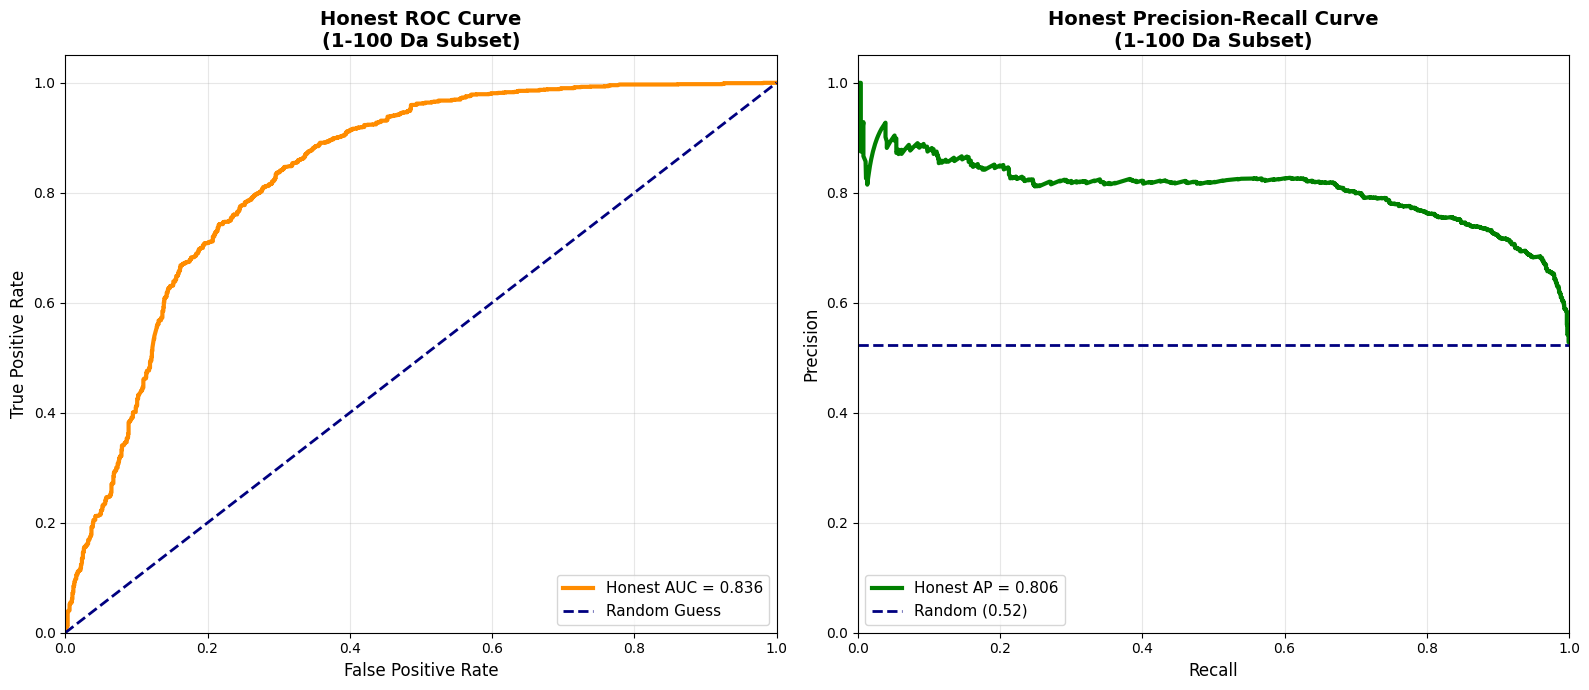

In [27]:
plot_honest_curves()

## Honest Mass Regime + Confident Spectrum Evaluation

In [15]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

In [17]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/results_stratified_binary_07_dataset_test.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
OUTPUT_DIR = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [18]:
def run_dual_filtered_eval():
    print("--- DUAL-FILTERED EVALUATION (HONEST MASS + HIGH CONFIDENCE SPECTRUM) ---")
    
    # 1. LOAD & ENRICH
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results file at {RESULTS_PATH}")
        return

    print("Loading results and enriching with mass data...")
    df = pd.read_csv(RESULTS_PATH)
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    if 'spec_id' in spec_df.columns: spec_df = spec_df.set_index('spec_id')
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    
    mass_lookup = spec_df[mz_col]
    df['mz_main'] = df['name_main'].map(mass_lookup)
    df['mz_sub'] = df['name_sub'].map(mass_lookup)
    df['mass_diff'] = (df['mz_main'] - df['mz_sub']).abs()
    
    n_total = len(df)
    
    # 2. APPLY FILTER 1: HONEST MASS REGIME
    # 1.0 <= Mass Diff <= 100.0
    mask_mass = (df['mass_diff'] >= 1.0) & (df['mass_diff'] <= 100.0)
    
    # 3. APPLY FILTER 2: HIGH-CONFIDENCE SPECTRUM
    # Sim < 0.4 (Distinct) OR Sim >= 0.7 (High Similarity)
    mask_spectrum = (df['cosine_similarity'] < 0.35) | (df['cosine_similarity'] >= 0.75)
    
    # 4. COMBINE FILTERS
    mask_final = mask_mass & mask_spectrum
    df_clean = df[mask_final].copy()
    
    n_kept = len(df_clean)
    print(f"\nOriginal Dataset:    {n_total:,}")
    print(f"Dual-Filtered Subset:{n_kept:,} ({n_kept/n_total:.1%} of data)")
    print(f"Criteria: 1.0<=dMass<=100.0 AND (Sim<0.4 OR Sim>=0.7)")

    # 5. CALCULATE METRICS
    y_true = df_clean['true_label'].values
    y_pred = df_clean['predicted_label'].values
    y_prob = df_clean['prob_similarity'].values
    
    # Curves
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()
    
    metrics = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'PR-AUC'],
        'Score': [
            accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred),
            recall_score(y_true, y_pred),
            f1_score(y_true, y_pred),
            roc_auc,
            pr_auc
        ]
    }
    
    df_metrics = pd.DataFrame(metrics)
    
    print("\n" + "="*50)
    print("  RESULTS ON 'IDEAL OPERATING' SUBSET  ")
    print("="*50)
    print(df_metrics.to_string(index=False, formatters={'Score': '{:.4f}'.format}))
    
    # 6. PLOTTING
    plt.figure(figsize=(16, 7))
    
    # ROC
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='purple', lw=3, label=f'Dual-Filtered AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve\n(Honest Mass + High Confidence Spectrum)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # PR
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='darkgreen', lw=3, label=f'Dual-Filtered AP = {pr_auc:.3f}')
    plt.axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve\n(Honest Mass + High Confidence Spectrum)')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save
    plot_path = os.path.join(OUTPUT_DIR, "dual_filtered_curves.png")
    plt.savefig(plot_path, dpi=300)
    csv_path = os.path.join(OUTPUT_DIR, "dual_filtered_metrics.csv")
    df_metrics.to_csv(csv_path, index=False)
    
    print(f"\nSaved metrics to {csv_path}")
    print(f"Saved plot to {plot_path}")
    plt.show()

--- DUAL-FILTERED EVALUATION (HONEST MASS + HIGH CONFIDENCE SPECTRUM) ---
Loading results and enriching with mass data...

Original Dataset:    4,858
Dual-Filtered Subset:2,063 (42.5% of data)
Criteria: 1.0<=dMass<=100.0 AND (Sim<0.4 OR Sim>=0.7)

  RESULTS ON 'IDEAL OPERATING' SUBSET  
   Metric  Score
 Accuracy 0.8846
Precision 0.9400
   Recall 0.8823
 F1 Score 0.9103
  ROC-AUC 0.9505
   PR-AUC 0.9706

Saved metrics to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/dual_filtered_metrics.csv
Saved plot to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/dual_filtered_curves.png


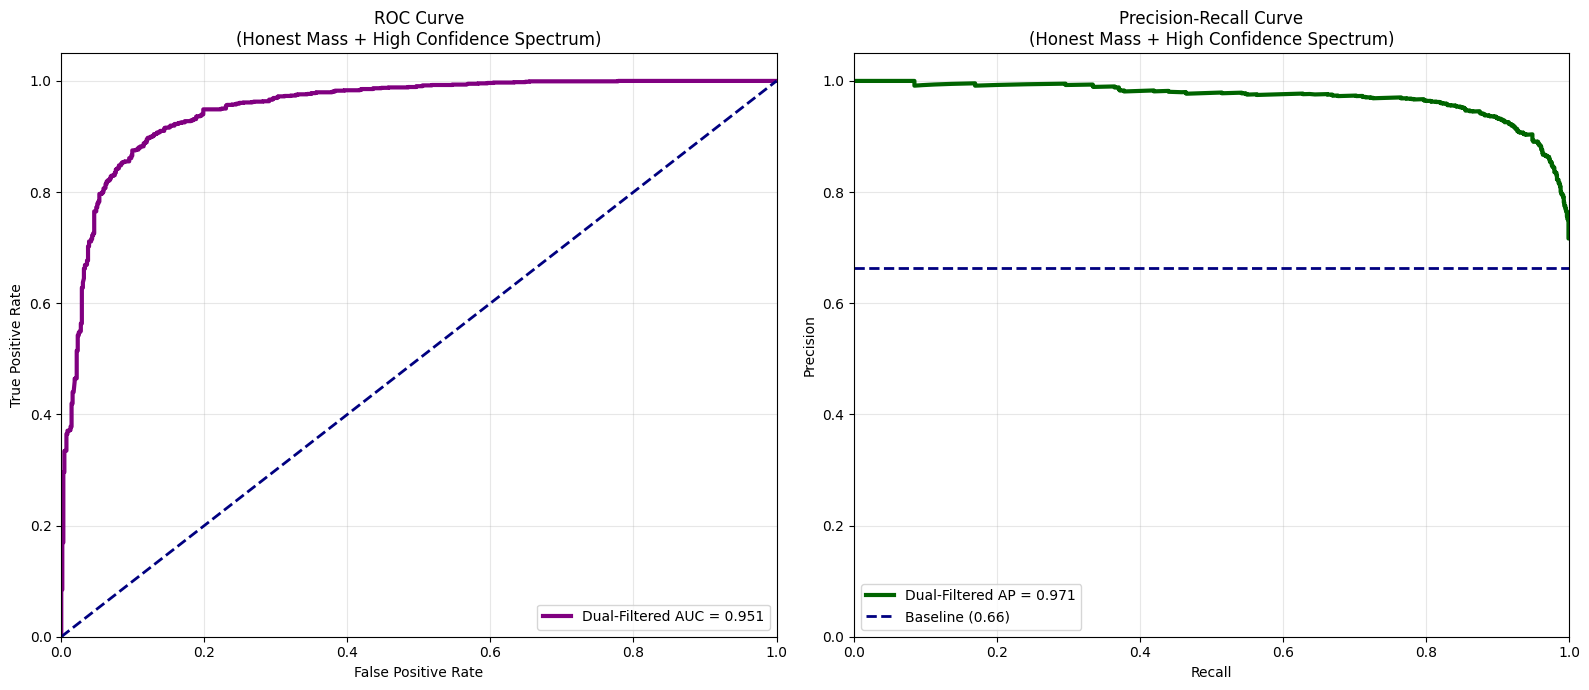

In [19]:
run_dual_filtered_eval()

## Calculate the confusion matrix in the ideal range

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, accuracy_score

In [5]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/results_stratified_binary_07_dataset_test.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
OUTPUT_DIR = "./results/final_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [24]:
def plot_ideal_confusion_matrix():
    print("--- GENERATING CONFUSION MATRIX FOR IDEAL ZONE ---")
    
    # 1. LOAD & ENRICH
    if not os.path.exists(RESULTS_PATH):
        print(f"Error: Could not find results at {RESULTS_PATH}")
        return
        
    print("Loading data...")
    df = pd.read_csv(RESULTS_PATH)
    spec_df = pd.read_pickle(SPEC_DATA_PATH)
    
    # Set index for fast mass lookup
    if 'spec_id' in spec_df.columns: spec_df = spec_df.set_index('spec_id')
    mz_col = 'precursor_mz' if 'precursor_mz' in spec_df.columns else 'prec_mz'
    
    # Calculate Mass Diffs
    mass_lookup = spec_df[mz_col]
    df['mass_diff'] = (df['name_main'].map(mass_lookup) - df['name_sub'].map(mass_lookup)).abs()
    
    # 2. APPLY "IDEAL ZONE" FILTERS
    # Filter A: Honest Mass Regime (1 - 100 Da)
    mask_mass = (df['mass_diff'] >= 1.0) & (df['mass_diff'] <= 100.0)
    
    # Filter B: High-Confidence Spectrum (Exclude 0.4 - 0.7)
    # We keep < 0.4 (Clear Negatives) and >= 0.7 (Clear Positives)
    mask_spectrum = (df['cosine_similarity'] < 0.35) | (df['cosine_similarity'] >= 0.75)
    
    df_ideal = df[mask_mass & mask_spectrum].copy()
    
    print(f"Original Pairs: {len(df):,}")
    print(f"Ideal Zone Pairs: {len(df_ideal):,} (Mass 1-100Da + Sim <0.35 or >0.75)")

    # 3. COMPUTE MATRIX
    y_true = df_ideal['true_label']
    y_pred = df_ideal['predicted_label']
    
    # Labels: 0 (Distinct), 1 (Similar)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    # Extract counts
    tn, fp, fn, tp = cm.ravel()
    
    # 4. VISUALIZATION
    plt.figure(figsize=(8, 6))
    
    # Create labels for the heatmap cells
    group_names = ['True Neg','False Pos','False Neg','True Pos']
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten()/np.sum(cm)]
    
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Predicted Distinct (0)', 'Predicted Similar (1)'],
                yticklabels=['Actual Distinct (0)', 'Actual Similar (1)'],
                annot_kws={"size": 14})
    
    plt.title('Confusion Matrix: Ideal Operating Zone\n(Honest Mass + High Confidence Spectrum)', fontsize=14)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    
    # 5. SAVE
    plot_path = os.path.join(OUTPUT_DIR, "ideal_confusion_matrix.png")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    print(f"\nPlot saved to {plot_path}")
    plt.show()
    
    # 6. PRINT METRICS
    acc = accuracy_score(y_true, y_pred)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print("\n--- MATRIX STATISTICS ---")
    print(f"True Positives (Correct Matches):  {tp:,}")
    print(f"True Negatives (Correct Rejects):  {tn:,}")
    print(f"False Positives (Type I Error):    {fp:,}  <-- 'Hallucinations'")
    print(f"False Negatives (Type II Error):   {fn:,}  <-- 'Missed Analogs'")
    print(f"---------------------------------")
    print(f"Accuracy in Ideal Zone: {acc:.4f}")
    print(f"Precision (Trustworthiness): {precision:.4f}")
    print(f"Recall (Discovery Power): {recall:.4f}")

--- GENERATING CONFUSION MATRIX FOR IDEAL ZONE ---
Loading data...
Original Pairs: 4,858
Ideal Zone Pairs: 2,063 (Mass 1-100Da + Sim <0.35 or >0.75)

Plot saved to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/ideal_confusion_matrix.png


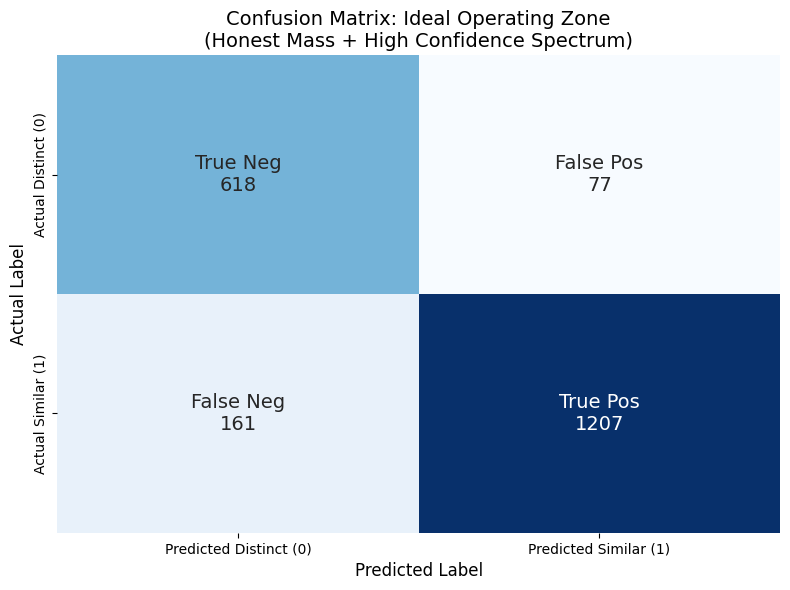


--- MATRIX STATISTICS ---
True Positives (Correct Matches):  1,207
True Negatives (Correct Rejects):  618
False Positives (Type I Error):    77  <-- 'Hallucinations'
False Negatives (Type II Error):   161  <-- 'Missed Analogs'
---------------------------------
Accuracy in Ideal Zone: 0.8846
Precision (Trustworthiness): 0.9400
Recall (Discovery Power): 0.8823


In [25]:
plot_ideal_confusion_matrix()

## Stress test the new model with uncertainty modelling

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, 
                             average_precision_score, accuracy_score,
                             confusion_matrix, precision_score, recall_score, f1_score)
import os

In [31]:
# --- CONFIGURATION ---
RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/results_stratified_binary_07_dataset_test.csv" 
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
CONF_LOW = 0.4
CONF_HIGH = 0.8

In [32]:
def plot_uncertainty_analysis():
    print(f"Loading results from {RESULTS_PATH}...")
    try:
        df = pd.read_csv(RESULTS_PATH)
    except FileNotFoundError:
        print("File not found! Please run the test script first.")
        return

    # --- 1. DATA PREPARATION ---
    y_true = df['true_label'].values
    y_prob = df['prob_similarity'].values
    
    # Create the "Trust Mask" (Exclude 0.4 - 0.7)
    mask_confident = (y_prob <= CONF_LOW) | (y_prob >= CONF_HIGH)
    
    # Data Subsets
    y_true_conf = y_true[mask_confident]
    y_prob_conf = y_prob[mask_confident]
    
    # Get actual binary predictions for the confident set (Threshold at 0.5)
    y_pred_conf = (y_prob_conf >= 0.5).astype(int)
    
    coverage = len(y_true_conf) / len(y_true)
    print(f"\nGlobal Coverage: {coverage:.1%} (Data retained after filtering)")

    # --- 2. CALCULATE METRICS FOR CONFIDENT REGIME ---
    # Confusion Matrix
    cm = confusion_matrix(y_true_conf, y_pred_conf)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate performance metrics
    acc = accuracy_score(y_true_conf, y_pred_conf)
    prec = precision_score(y_true_conf, y_pred_conf, zero_division=0)
    rec = recall_score(y_true_conf, y_pred_conf, zero_division=0)
    f1 = f1_score(y_true_conf, y_pred_conf, zero_division=0)

    # Print the requested statistics
    print("\n--- MATRIX STATISTICS (Confident Regime) ---")
    print(f"True Positives (Correct Matches):  {tp:,}")
    print(f"True Negatives (Correct Rejects):  {tn:,}")
    print(f"False Positives (Type I Error):    {fp:,}  <-- 'Hallucinations'")
    print(f"False Negatives (Type II Error):   {fn:,}  <-- 'Missed Analogs'")
    print("-" * 40)
    print(f"Accuracy in Ideal Zone:       {acc:.4f}")
    print(f"Precision (Trustworthiness):  {prec:.4f}")
    print(f"Recall (Discovery Power):     {rec:.4f}")
    print(f"F1 score:                     {f1:.4f}\n")

    # --- 3. PLOTTING ---
    # Adjusted figure size to accommodate 4 plots
    plt.figure(figsize=(24, 6))
    
    # PLOT A: ROC Comparison
    plt.subplot(1, 4, 1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    base_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='grey', linestyle='--', label=f'All Data (AUC={base_auc:.3f})')
    
    fpr_c, tpr_c, _ = roc_curve(y_true_conf, y_prob_conf)
    conf_auc = auc(fpr_c, tpr_c)
    plt.plot(fpr_c, tpr_c, color='purple', lw=3, label=f'Confident Only (AUC={conf_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Improvement')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    # PLOT B: PR Comparison
    plt.subplot(1, 4, 2)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
    base_ap = average_precision_score(y_true, y_prob)
    plt.plot(rec_curve, prec_curve, color='grey', linestyle='--', label=f'All Data (AP={base_ap:.3f})')
    
    prec_curve_c, rec_curve_c, _ = precision_recall_curve(y_true_conf, y_prob_conf)
    conf_ap = average_precision_score(y_true_conf, y_prob_conf)
    plt.plot(rec_curve_c, prec_curve_c, color='green', lw=3, label=f'Confident Only (AP={conf_ap:.3f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Boost')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    
    # PLOT C: Risk-Coverage Curve
    plt.subplot(1, 4, 3)
    confidence_scores = np.abs(y_prob - 0.5)
    sorted_indices = np.argsort(confidence_scores)
    
    x_coverage = []
    y_accuracy = []
    n_samples = len(y_true)
    step = int(n_samples * 0.01)
    
    for i in range(0, n_samples - step, step):
        current_indices = sorted_indices[i:] 
        curr_y_true = y_true[current_indices]
        curr_y_prob = y_prob[current_indices]
        curr_y_pred = (curr_y_prob > 0.5).astype(int)
        
        acc_sweep = accuracy_score(curr_y_true, curr_y_pred)
        cov_sweep = len(curr_y_true) / n_samples
        
        x_coverage.append(cov_sweep)
        y_accuracy.append(acc_sweep)
        
    plt.plot(x_coverage, y_accuracy, lw=3, color='blue')
    plt.axvline(x=coverage, color='red', linestyle='--', label=f'Current Setting ({coverage:.0%})')
    
    plt.xlabel('Coverage (Fraction of Data Retained)')
    plt.ylabel('Accuracy on Retained Data')
    plt.title('Risk-Coverage Curve')
    plt.gca().invert_xaxis()
    plt.legend()
    plt.grid(alpha=0.3)

    # PLOT D: Confusion Matrix for Confident Data
    plt.subplot(1, 4, 4)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix\n(Confident Data Only, Cov={coverage:.0%})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    plt.tight_layout()
    plt.savefig("uncertainty_analysis_plots_with_cm.png", dpi=300)
    plt.show()

Loading results from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/results_stratified_binary_07_dataset_test.csv...

Global Coverage: 52.2% (Data retained after filtering)

--- MATRIX STATISTICS (Confident Regime) ---
True Positives (Correct Matches):  811
True Negatives (Correct Rejects):  1,445
False Positives (Type I Error):    107  <-- 'Hallucinations'
False Negatives (Type II Error):   173  <-- 'Missed Analogs'
----------------------------------------
Accuracy in Ideal Zone:       0.8896
Precision (Trustworthiness):  0.8834
Recall (Discovery Power):     0.8242
F1 score:                     0.8528



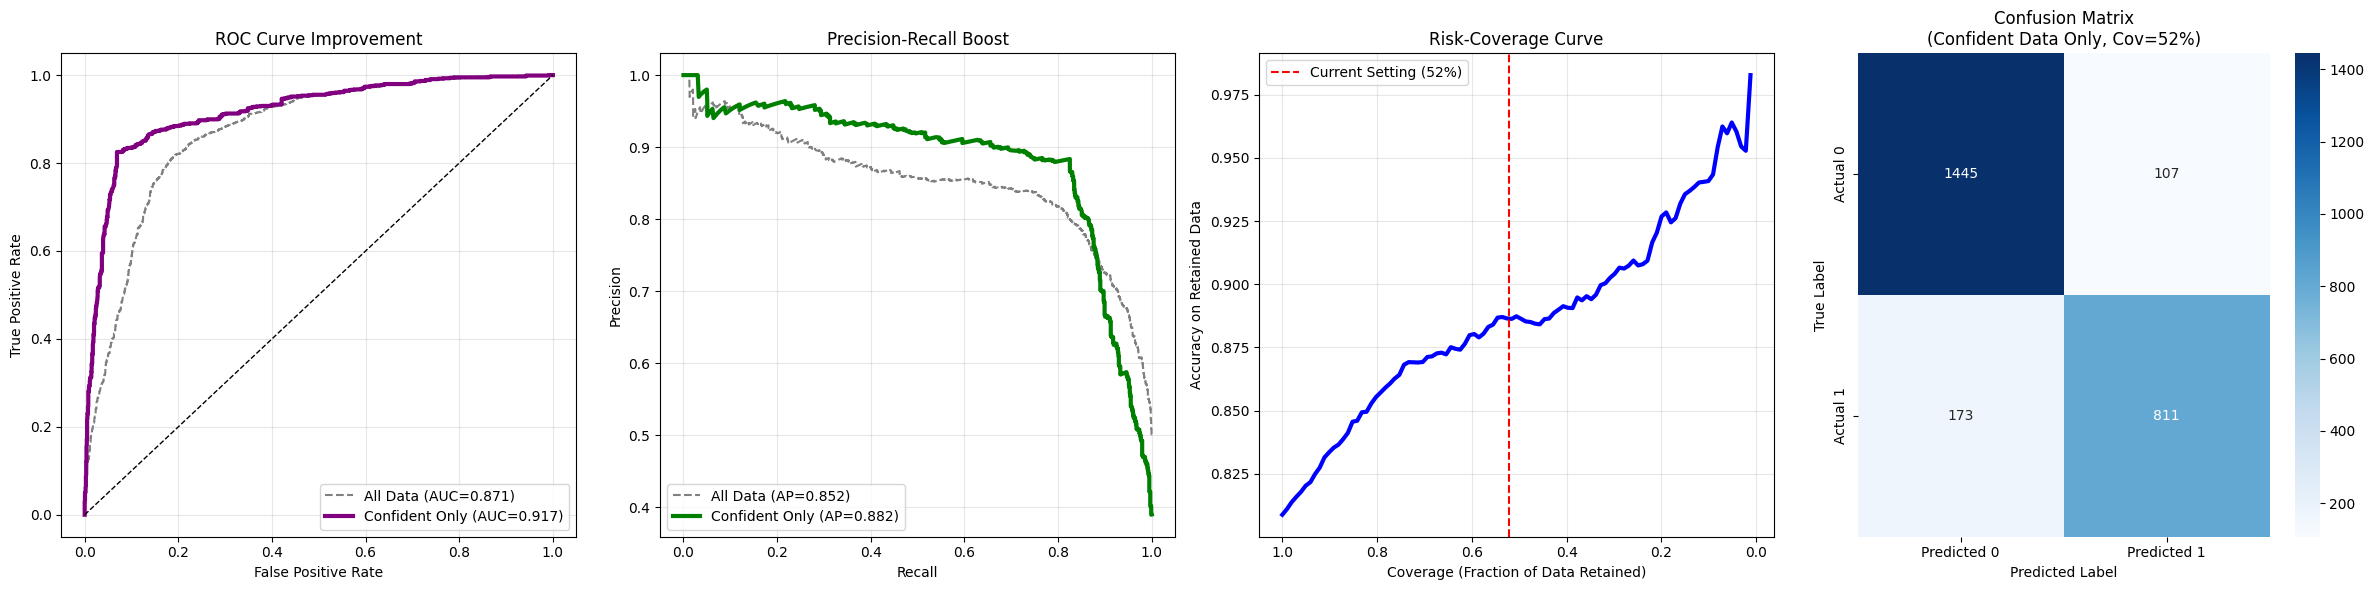

In [33]:
plot_uncertainty_analysis()